In [13]:
%load_ext autoreload
%autoreload 2
    
import numpy as np
import torch
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data
from sklearn.model_selection import train_test_split

import sys
from pathlib import Path

parent_dir = Path.cwd().parent
sys.path.append(str(parent_dir))

import models.gnn

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Load and split a graph dataset with atom-type node features (and activities)

In [14]:

graphs_list = torch.load('../data_collection/graphs_at_types_only.pt', weights_only=False)

graphs_train, graphs_val = train_test_split(
    graphs_list,
    test_size=0.10,     
    random_state=42     
)


train_loader = DataLoader(
    graphs_train, 
    batch_size=300,   
    shuffle=True   
)

val_loader = DataLoader(
    graphs_val, 
    batch_size=300,   
    shuffle=True   
)

device = torch.device("cpu")

Train a custom model with SAGEConv layers (see ../models/gnn.py) to predict activity values

In [15]:
epochs = 100
model = gnn.SAGEC(16, 256, 128, 16, 1).to(device)
model.fit(train_loader, val_loader, device, epochs=epochs)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [03:00<00:00,  1.80s/it]


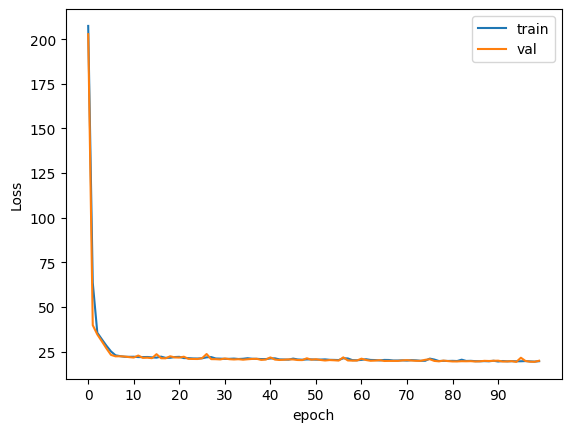

R² Train Score: 0.217
Train RMSE:     ±0.887
Train MAE:      ±0.670
R² Val Score: 0.189
Val RMSE:     ±0.897
Val MAE:      ±0.680


In [16]:
plt.plot(model.train_loss, label='train')
plt.plot(model.val_loss, label='val')

plt.legend()
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.xticks(range(0, epochs, 10))
plt.show()

model.eval()
model.analysis(train_loader, val_loader, device)

Train a custom model with GINConv layers (see ../models/gnn.py) to predict activity values

In [17]:
epochs = 100
model = gnn.GINConv(16, 256, 128, 16, 1).to(device)
model.fit(train_loader, val_loader, device, epochs=epochs)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [02:20<00:00,  1.41s/it]


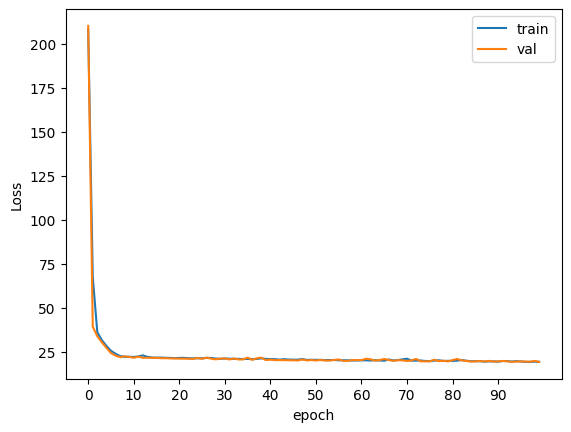

R² Train Score: 0.252
Train RMSE:     ±0.867
Train MAE:      ±0.658
R² Val Score: 0.229
Val RMSE:     ±0.874
Val MAE:      ±0.663


In [18]:
plt.plot(model.train_loss, label='train')
plt.plot(model.val_loss, label='val')

plt.legend()
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.xticks(range(0, epochs, 10))
plt.show()

model.eval()
model.analysis(train_loader, val_loader, device)

Train a custom model with GraphConv layers (see ../models/gnn.py) to predict activity values

In [ ]:
epochs = 100
model = gnn.GraphConv(16, 256, 128, 16, 1).to(device)
model.fit(train_loader, val_loader, device, epochs=epochs)

 21%|██████████████████████████████████▍                                                                                                                                 | 21/100 [00:29<01:54,  1.45s/it]

In [ ]:
plt.plot(model.train_loss, label='train')
plt.plot(model.val_loss, label='val')

plt.legend()
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.xticks(range(0, epochs, 10))
plt.show()

model.eval()
model.analysis(train_loader, val_loader, device)

Train a custom model with GatedGraphConv layers (see ../models/gnn.py) to predict activity values

In [ ]:
epochs = 100
model = gnn.GatedGraphConv(16, 128, 16, 1).to(device)
model.fit(train_loader, val_loader, device, epochs=epochs)

In [ ]:
plt.plot(model.train_loss, label='train')
plt.plot(model.val_loss, label='val')

plt.legend()
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.xticks(range(0, epochs, 10))
plt.show()

model.eval()
model.analysis(train_loader, val_loader, device)

Train a custom model with ResGatedGraphConv layers (see ../models/gnn.py) to predict activity values

In [ ]:
epochs = 100
model = gnn.ResGatedGraphConv(16, 256, 128, 16, 1).to(device)
model.fit(train_loader, val_loader, device, epochs=epochs)

In [ ]:
plt.plot(model.train_loss, label='train')
plt.plot(model.val_loss, label='val')

plt.legend()
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.xticks(range(0, epochs, 10))
plt.show()

model.eval()
model.analysis(train_loader, val_loader, device)

Train a custom model with GATConv layers (see ../models/gnn.py) to predict activity values

In [ ]:
epochs = 100
model = gnn.GATConv(16, 256, 128, 16, 1).to(device)
model.fit(train_loader, val_loader, device, epochs=epochs)

In [ ]:
plt.plot(model.train_loss, label='train')
plt.plot(model.val_loss, label='val')

plt.legend()
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.xticks(range(0, epochs, 10))
plt.show()

model.eval()
model.analysis(train_loader, val_loader, device)